In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels, PLaxfromClass
from scipy.integrate import odeint
import functools
import vegas
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})
fact=(2*np.pi)**3


In [13]:
t_ini = -7
fullt=np.linspace(t_ini,3, 300)
teval=0
supprshift=8
p=2

ma=1.e-25
fx=0.1
h=0.67810
kref =8.4e12 * pow(ma/h,1/2) * 0.666**0.25
zeval=0.5
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.01, p=p, supprshift=supprshift)
def g_ank(k):
    return nk.g_an(-(2+p)*np.log(k/kref))
def h_ank(k):
    return nk.h_an(-(2+p)*np.log(k/kref))

def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))
def h_numk(k):
    return nk.h_num(-(2+p)*np.log(k/kref))

plclass = PLaxfromClass(fx=fx, m_a_ev=ma, zeval=zeval)
PLc_int = plclass.PLc_int

In [14]:
def prescription_int_22(vars,kev):
    logq=vars[0]
    q = np.exp(logq)
    mu=vars[1]
    g_k=nk.g_num(-(2+p)*np.log(kev/kref));h_k=nk.h_num(-(2+p)*np.log(kev/kref))

    kMq = np.sqrt(kev*kev + q*q - 2*kev*q*mu)
    kPq = np.sqrt(kev*kev + q*q + 2*kev*q*mu)
    P22dcdc=0; P22dcTc=0; P22dcdx=0; P22dcTx=0; P22dxdx=0
    if kMq>q:
        P22dcdc+=2*q*q*(nk.F2_0(kev,q,mu)**2)*PLc_int(q)*PLc_int(kMq)
        P22dcTc+=2*q*q*(nk.F2_0(kev,q,mu)*nk.G2_0(kev,q,mu))*nk.g_c_int(-(2+p)*np.log(kev/kref))*PLc_int(q)*PLc_int(kMq)
        P22dcdx+=2*q*q*g_k*(nk.F2_0(kev,q,mu)**2)*PLc_int(q)*PLc_int(kMq)
        P22dcTx+=2*q*q*h_k*(nk.F2_0(kev,q,mu)*nk.G2_0(kev,q,mu))*PLc_int(q)*PLc_int(kMq)
        P22dxdx+=2*q*q*g_k*g_k*(nk.F2_0(kev,q,mu)**2)*PLc_int(q)*PLc_int(kMq)
    if kPq>q:
        P22dcdc+=2*q*q*(nk.F2_0(kev,q,-mu)**2)*PLc_int(q)*PLc_int(kPq)
        P22dcTc+=2*q*q*(nk.F2_0(kev,q,-mu)*nk.G2_0(kev,q,-mu))*nk.g_c_int(-(2+p)*np.log(kev/kref))*PLc_int(q)*PLc_int(kPq)
        P22dcdx+=2*q*q*g_k*(nk.F2_0(kev,q,-mu)**2)*PLc_int(q)*PLc_int(kPq)
        P22dcTx+=2*q*q*h_k*(nk.F2_0(kev,q,-mu)*nk.G2_0(kev,q,-mu))*PLc_int(q)*PLc_int(kPq)
        P22dxdx+=2*q*q*g_k*g_k*(nk.F2_0(kev,q,-mu)**2)*PLc_int(q)*PLc_int(kPq)
    intf=4*q*np.pi/fact
    return [intf*P22dcdc,intf*P22dcTc,intf*P22dcdx,intf*P22dcTx,intf*P22dxdx]


def prescription_int_13(vars,kev):
    logq=vars[0]
    q = np.exp(logq)
    mu=vars[1]
    g_k=nk.g_num(-(2+p)*np.log(kev/kref));h_k=nk.h_num(-(2+p)*np.log(kev/kref))

    P13dcdc=6*q*q*(nk.F3_0(kev,q,mu))*PLc_int(q)*PLc_int(kev)
    P13dcTc=3*q*q*(nk.F3_0(kev,q,mu)+ nk.G3_0(kev,q,mu))*nk.g_c_int(-(2+p)*np.log(kev/kref))*PLc_int(q)*PLc_int(kev)
    P13dcdx=6*q*q*g_k*(nk.F3_0(kev,q,mu))*PLc_int(q)*PLc_int(kev)
    P13dcTx=3*q*q*h_k*(nk.F3_0(kev,q,mu) + nk.G3_0(kev,q,mu))*PLc_int(q)*PLc_int(kev)
    P13dxdx=6*q*q*g_k*g_k*(nk.F3_0(kev,q,mu))*PLc_int(q)*PLc_int(kev)

    intf=4*q*np.pi/fact
    return [intf*P13dcdc,intf*P13dcTc,intf*P13dcdx,intf*P13dcTx,intf*P13dxdx]

In [15]:
kevList = np.logspace(-2,0,10)

res22 = []; res13 = []

for kEval in kevList:
    integ = vegas.Integrator([[np.log(1.e-3), np.log(5.)], [0., 1.]],mpi=True, nproc=70)

    retl = [a.mean for a in integ(functools.partial(prescription_int_22, kev=kEval),neval=500)]
    res22.append(retl)


    retl = [a.mean for a in integ(functools.partial(prescription_int_13, kev=kEval),neval=500)]
    res13.append(retl)

    print(f'At k={kEval:.3f} done', end='\r')
res22 = np.array(res22).T
res13 = np.array(res13).T
traindcdc13,traindcTc13,traindcdx13,traindcTx13,traindxdx13 = res13
traindcdc22,traindcTc22,traindcdx22,traindcTx22,traindxdx22 = res22

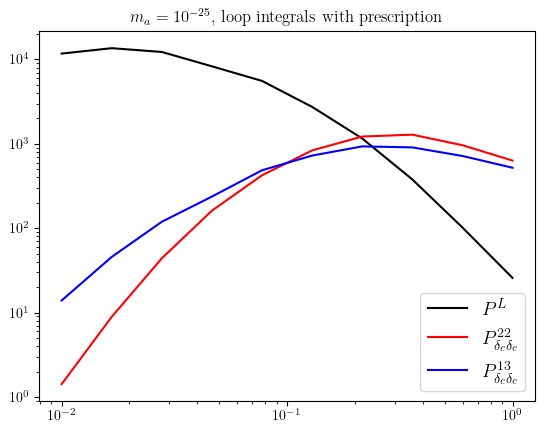

In [16]:
plt.loglog(kevList, PLc_int(kevList), 'k',label='$P^L$')
plt.loglog(kevList, traindcdc22,'r',label='$P_{\delta_c\delta_c}^{22}$')
plt.loglog(kevList, -traindcdc13,'b',label='$P_{\delta_c\delta_c}^{13}$')

# plt.loglog(kevList, traindcdx22,'darkorange',label='$P_{\delta_c\delta_\chi}^{22}$')
# plt.loglog(kevList,pow(kevList/kevList[0],4)*traindcdx22[0],'m--',label='$\sim k^4$')

# plt.loglog(kevList,-pow(kevList/kevList[0],3)*traindcdc13[0])
plt.legend(fontsize=14)
plt.title('$m_a=10^{-25}$, loop integrals with prescription')
plt.show()